# Hybrid Prophet + LSTM Training

Notebook này huấn luyện mô hình lai giữa Facebook Prophet và LSTM để dự báo `memory_usage_pct`, `cpu_total_usage`, `system_load`. Quy trình:

1. Prophet mô hình hóa xu hướng + seasonality trên chuỗi train.
2. Sai số (residuals) trên phần train được dùng để huấn luyện LSTM nhằm học các mẫu phi tuyến phức tạp mà Prophet chưa giải thích được.
3. Trong giai đoạn dự báo, Prophet dự đoán trước, LSTM dự báo residual tương lai theo kiểu autoregressive, cuối cùng cộng lại tạo thành dự báo hybrid.

> **Lưu ý**: Cần cài thêm `prophet` (hoặc `fbprophet` tùy môi trường) và `torch` trước khi chạy notebook này.


In [1]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from prophet import Prophet

from model_utils import (
    calculate_metrics,
    print_metrics,
    save_results,
    save_model,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f"{x:,.6f}")

np.random.seed(42)
torch.manual_seed(42)

print("✓ Libraries imported")


Importing plotly failed. Interactive plots will not work.


✓ Libraries imported


In [3]:
import os

current_dir = os.getcwd()
print("Current working directory:", current_dir)
print("Subfolders present:")
for entry in os.listdir(current_dir):
    if os.path.isdir(os.path.join(current_dir, entry)):
        print("  -", entry)


Current working directory: /content
Subfolders present:
  - .config
  - sample_data


In [ ]:
# Configuration - HYBRID V2 (Prophet nhẹ, LSTM mạnh)
DATA_DIR = Path('processed_data')
MODELS_DIR = Path('models')
RESULTS_FILE = Path('results_hybrid_prophet_lstm.json')
TARGETS = ['memory_usage_pct', 'cpu_total_usage', 'system_load']

# Time axis assumptions (30s cadence như các notebook khác)
SERIES_FREQ = '30S'
START_TIMESTAMP = pd.Timestamp('2024-01-01 00:00:00')

# Prophet config: chỉ giữ trend dài hạn, tránh overfit spikes 30s
PROPHET_CONFIG = {
    'seasonality_mode': 'multiplicative',
    'weekly_seasonality': False,
    'daily_seasonality': False,
    'yearly_seasonality': False,
    'changepoint_prior_scale': 0.03,
    'changepoint_range': 0.85,
    'n_changepoints': 20,
    'seasonality_prior_scale': 0.5,
    'interval_width': 0.80,
    'uncertainty_samples': 0,
}

# LSTM residual config: lấy lại signal high-frequency + spikes
WINDOW_SIZE = 960       
HIDDEN_SIZE = 128
NUM_LAYERS = 3
DROPOUT = 0.25

EPOCHS = 25
BATCH_SIZE = 128
LEARNING_RATE = 3e-4

# Training improvements (giữ nguyên nhưng tinh chỉnh patience/LR min)
USE_HUBER_LOSS = True
USE_LR_SCHEDULER = True
USE_EARLY_STOPPING = True
EARLY_STOP_PATIENCE = 8
LR_PATIENCE = 4
LR_FACTOR = 0.5
MIN_LR = 5e-6
GRAD_CLIP_MAX_NORM = 1.0

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MODELS_DIR.mkdir(exist_ok=True)
print(f"Models dir: {MODELS_DIR.resolve()}")
print(f"Device: {DEVICE}")
print(f"✓ Config loaded: Window={WINDOW_SIZE}, Hidden={HIDDEN_SIZE}, Layers={NUM_LAYERS}")


Models dir: C:\Users\AnPham\Documents\PROJECTS\Intern1\models
Device: cpu
✓ Config loaded: Window=96, Hidden=128, Layers=3


In [13]:
# Load datasets

def load_target_series(target: str):
    train_path = DATA_DIR / target / 'y_train.csv'
    test_path = DATA_DIR / target / 'y_test.csv'
    y_train = pd.read_csv(train_path).squeeze()
    y_test = pd.read_csv(test_path).squeeze()
    return y_train, y_test


datasets = {}
for target in TARGETS:
    y_train, y_test = load_target_series(target)
    datasets[target] = {
        'y_train': y_train,
        'y_test': y_test,
        'n_train': len(y_train),
        'n_test': len(y_test),
    }
    print(f"{target}: train={len(y_train):,} | test={len(y_test):,}")

print("\n✓ Series loaded")


memory_usage_pct: train=68,599 | test=17,150
cpu_total_usage: train=68,599 | test=17,150
system_load: train=68,599 | test=17,150

✓ Series loaded


In [14]:
# Helper functions

class ResidualDataset(Dataset):
    def __init__(self, sequences, targets):
        self.X = torch.tensor(sequences, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(targets, dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class LSTMResidualModel(nn.Module):
    def __init__(self, hidden_size=64, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out


def build_time_index(length: int, freq: str = SERIES_FREQ, start_ts: pd.Timestamp = START_TIMESTAMP):
    return pd.date_range(start=start_ts, periods=length, freq=freq)


def create_sequences(values: np.ndarray, window_size: int):
    X, y = [], []
    for i in range(window_size, len(values)):
        X.append(values[i - window_size:i])
        y.append(values[i])
    return np.array(X), np.array(y)


def train_lstm(model, dataloader, epochs, lr, 
               use_huber_loss=True, use_lr_scheduler=True, 
               use_early_stopping=True, early_stop_patience=10,
               lr_patience=5, lr_factor=0.5, min_lr=1e-5,
               grad_clip_max_norm=1.0):
    """
    Improved LSTM training với:
    - Huber loss (ít nhạy với outliers hơn MSE)
    - Learning rate scheduler
    - Early stopping
    - Gradient clipping
    """
    # Chọn loss function
    if use_huber_loss:
        criterion = nn.HuberLoss(delta=1.0)  # delta=1.0: ít nhạy với outliers
    else:
        criterion = nn.MSELoss()
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Learning rate scheduler
    scheduler = None
    if use_lr_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=lr_factor, patience=lr_patience, 
            min_lr=min_lr, verbose=False
        )
    
    # Early stopping
    best_loss = float('inf')
    patience_counter = 0
    
    model.train()
    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            
            # Gradient clipping để tránh exploding gradients
            if grad_clip_max_norm > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_max_norm)
            
            optimizer.step()
            epoch_loss += loss.item() * len(X_batch)
        
        epoch_loss /= len(dataloader.dataset)
        
        # Update learning rate
        if scheduler is not None:
            scheduler.step(epoch_loss)
        
        # Early stopping check
        if use_early_stopping:
            if epoch_loss < best_loss:
                best_loss = epoch_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= early_stop_patience:
                    current_lr = optimizer.param_groups[0]['lr']
                    print(f"    Early stopping at epoch {epoch} (best loss: {best_loss:.6f}, current lr: {current_lr:.6f})")
                    break
        
        # Print progress
        if epoch % 5 == 0 or epoch == 1 or epoch == epochs:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"    Epoch {epoch:02d}/{epochs} - loss: {epoch_loss:.6f} - lr: {current_lr:.6f}")


def predict_sequences(model, sequences):
    model.eval()
    with torch.no_grad():
        X = torch.tensor(sequences, dtype=torch.float32).unsqueeze(-1).to(DEVICE)
        preds = model(X).cpu().numpy().flatten()
    return preds


def forecast_residuals(model, seed_sequence, n_steps):
    """Autoregressive residual forecast using last WINDOW_SIZE scaled residuals."""
    model.eval()
    seq = seed_sequence.copy().tolist()
    preds = []
    with torch.no_grad():
        for _ in range(n_steps):
            window = torch.tensor(seq[-WINDOW_SIZE:], dtype=torch.float32).view(1, WINDOW_SIZE, 1).to(DEVICE)
            pred = model(window).cpu().item()
            preds.append(pred)
            seq.append(pred)
    return np.array(preds)


def inverse_scale(values, mean, std):
    return values * std + mean


In [15]:
hybrid_models = {}
training_metadata = {}
summary_records = []
detailed_results = {}
prediction_store = {}

for target in TARGETS:
    print("\n" + "=" * 80)
    print(f"Target: {target}")
    print("=" * 80)

    y_train = datasets[target]['y_train'].reset_index(drop=True)
    y_test = datasets[target]['y_test'].reset_index(drop=True)
    n_train = len(y_train)
    n_test = len(y_test)
    total_len = n_train + n_test

    time_index = build_time_index(total_len)
    train_df = pd.DataFrame({'ds': time_index[:n_train], 'y': y_train.values})

    # ---- Prophet training ----
    print("Training Prophet...")
    prophet_start = time.time()
    prophet = Prophet(**PROPHET_CONFIG)
    prophet.fit(train_df)
    prophet_time = time.time() - prophet_start

    future_df = prophet.make_future_dataframe(periods=n_test, freq=SERIES_FREQ)
    forecast_df = prophet.predict(future_df)
    prophet_preds_all = forecast_df['yhat'].values
    prophet_train_pred = prophet_preds_all[:n_train]
    prophet_test_pred = prophet_preds_all[n_train:]

    # ---- Residual prep ----
    train_residuals = y_train.values - prophet_train_pred
    residual_mean = train_residuals.mean()
    residual_std = train_residuals.std() if train_residuals.std() > 0 else 1e-6
    residuals_scaled = (train_residuals - residual_mean) / residual_std

    if n_train <= WINDOW_SIZE:
        raise ValueError(f"WINDOW_SIZE ({WINDOW_SIZE}) phải nhỏ hơn số mẫu train ({n_train})")

    seq_X, seq_y = create_sequences(residuals_scaled, WINDOW_SIZE)
    residual_dataset = ResidualDataset(seq_X, seq_y)
    dataloader = DataLoader(residual_dataset, batch_size=BATCH_SIZE, shuffle=True)

    # ---- LSTM training ----
    print("Training LSTM on residuals...")
    lstm_model = LSTMResidualModel(hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT).to(DEVICE)
    lstm_start = time.time()
    train_lstm(
        lstm_model, dataloader, epochs=EPOCHS, lr=LEARNING_RATE,
        use_huber_loss=USE_HUBER_LOSS,
        use_lr_scheduler=USE_LR_SCHEDULER,
        use_early_stopping=USE_EARLY_STOPPING,
        early_stop_patience=EARLY_STOP_PATIENCE,
        lr_patience=LR_PATIENCE,
        lr_factor=LR_FACTOR,
        min_lr=MIN_LR,
        grad_clip_max_norm=GRAD_CLIP_MAX_NORM
    )
    lstm_time = time.time() - lstm_start

    # ---- Residual predictions ----
    train_pred_scaled = predict_sequences(lstm_model, seq_X)
    residual_train_pred = inverse_scale(train_pred_scaled, residual_mean, residual_std)

    residual_train_full = prophet_train_pred.copy()
    residual_train_full[:WINDOW_SIZE] = prophet_train_pred[:WINDOW_SIZE]
    hybrid_train_pred = prophet_train_pred.copy()
    hybrid_train_pred[WINDOW_SIZE:] = prophet_train_pred[WINDOW_SIZE:] + residual_train_pred

    seed_sequence = residuals_scaled[-WINDOW_SIZE:]
    residual_test_scaled = forecast_residuals(lstm_model, seed_sequence, n_test)
    residual_test_pred = inverse_scale(residual_test_scaled, residual_mean, residual_std)
    hybrid_test_pred = prophet_test_pred + residual_test_pred

    # ---- Metrics ----
    prophet_metrics = calculate_metrics(y_test.values, prophet_test_pred)
    hybrid_metrics = calculate_metrics(y_test.values, hybrid_test_pred)

    print("Prophet only metrics:")
    print_metrics(prophet_metrics, target + ' (Prophet)')
    print("Hybrid metrics:")
    print_metrics(hybrid_metrics, target + ' (Hybrid)')

    # ---- Save model package ----
    hybrid_package = {
        'prophet': prophet,
        'lstm_state_dict': lstm_model.state_dict(),
        'residual_mean': residual_mean,
        'residual_std': residual_std,
        'window_size': WINDOW_SIZE,
        'freq': SERIES_FREQ,
        'start_timestamp': START_TIMESTAMP.isoformat(),
        'config': {
            'prophet': PROPHET_CONFIG,
            'lstm': {
                'hidden_size': HIDDEN_SIZE,
                'num_layers': NUM_LAYERS,
                'dropout': DROPOUT,
                'epochs': EPOCHS,
                'batch_size': BATCH_SIZE,
                'learning_rate': LEARNING_RATE,
                'window_size': WINDOW_SIZE,
                'use_huber_loss': USE_HUBER_LOSS,
                'use_lr_scheduler': USE_LR_SCHEDULER,
                'use_early_stopping': USE_EARLY_STOPPING,
                'early_stop_patience': EARLY_STOP_PATIENCE,
                'lr_patience': LR_PATIENCE,
                'lr_factor': LR_FACTOR,
                'min_lr': MIN_LR,
                'grad_clip_max_norm': GRAD_CLIP_MAX_NORM,
            }
        }
    }

    model_path = save_model(
        hybrid_package,
        model_name='hybrid_prophet_lstm',
        target=target,
        config={
            'prophet': PROPHET_CONFIG,
            'lstm': {
                'hidden_size': HIDDEN_SIZE,
                'num_layers': NUM_LAYERS,
                'dropout': DROPOUT,
                'epochs': EPOCHS,
                'batch_size': BATCH_SIZE,
                'learning_rate': LEARNING_RATE,
                'window_size': WINDOW_SIZE,
                'use_huber_loss': USE_HUBER_LOSS,
                'use_lr_scheduler': USE_LR_SCHEDULER,
                'use_early_stopping': USE_EARLY_STOPPING,
                'early_stop_patience': EARLY_STOP_PATIENCE,
                'lr_patience': LR_PATIENCE,
                'lr_factor': LR_FACTOR,
                'min_lr': MIN_LR,
                'grad_clip_max_norm': GRAD_CLIP_MAX_NORM,
            }
        },
        models_dir=str(MODELS_DIR)
    )

    training_metadata[target] = {
        'prophet_time_s': prophet_time,
        'lstm_time_s': lstm_time,
        'model_path': model_path,
    }

    summary_records.append({
        'target': target,
        'prophet_mae': prophet_metrics['mae'],
        'prophet_rmse': prophet_metrics['rmse'],
        'prophet_r2': prophet_metrics['r2'],
        'hybrid_mae': hybrid_metrics['mae'],
        'hybrid_rmse': hybrid_metrics['rmse'],
        'hybrid_r2': hybrid_metrics['r2'],
        'prophet_time_s': prophet_time,
        'lstm_time_s': lstm_time,
        'model_path': model_path,
    })

    detailed_results[target] = {
        'prophet_metrics': prophet_metrics,
        'hybrid_metrics': hybrid_metrics,
        'prophet_time_s': prophet_time,
        'lstm_time_s': lstm_time,
        'model_path': model_path,
    }

    prediction_store[target] = {
        'y_train': y_train.values,
        'y_test': y_test.values,
        'prophet_train': prophet_train_pred,
        'prophet_test': prophet_test_pred,
        'hybrid_train': hybrid_train_pred,
        'hybrid_test': hybrid_test_pred,
    }

print("\n✓ Training completed for all targets")



Target: memory_usage_pct
Training Prophet...


18:08:30 - cmdstanpy - INFO - Chain [1] start processing
18:08:59 - cmdstanpy - INFO - Chain [1] done processing


Training LSTM on residuals...


c:\Users\AnPham\Documents\PROJECTS\Intern1\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


    Epoch 01/25 - loss: 0.065756 - lr: 0.000300
    Epoch 05/25 - loss: 0.017086 - lr: 0.000300
    Epoch 10/25 - loss: 0.014896 - lr: 0.000300
    Epoch 15/25 - loss: 0.014252 - lr: 0.000300
    Epoch 20/25 - loss: 0.014116 - lr: 0.000300
    Epoch 25/25 - loss: 0.013695 - lr: 0.000300
Prophet only metrics:

Metrics for memory_usage_pct (Prophet):
  MAE:         0.760953
  RMSE:        0.888618
  MAPE:        209.33%
  R²:          -0.008551
  Max Error:   7.321419
  Median AE:   0.642124
Hybrid metrics:

Metrics for memory_usage_pct (Hybrid):
  MAE:         1.957612
  RMSE:        2.120389
  MAPE:        490.21%
  R²:          -4.742465
  Max Error:   5.333994
  Median AE:   2.478757
✓ Model saved: models\hybrid_prophet_lstm_memory_usage_pct_20251126_203242.pkl

Target: cpu_total_usage
Training Prophet...


...

    Epoch 01/25 - loss: 0.237107 - lr: 0.000300
    Epoch 05/25 - loss: 0.208517 - lr: 0.000300
    Epoch 10/25 - loss: 0.190087 - lr: 0.000300
    Epoch 15/25 - loss: 0.179899 - lr: 0.000300
    Epoch 20/25 - loss: 0.171326 - lr: 0.000300
    Epoch 25/25 - loss: 0.164653 - lr: 0.000300
Prophet only metrics:

Metrics for cpu_total_usage (Prophet):
  MAE:         0.606707
  RMSE:        0.979300
  MAPE:        103.63%
  R²:          -0.002737
  Max Error:   14.295617
  Median AE:   0.450452
Hybrid metrics:

Metrics for cpu_total_usage (Hybrid):
  MAE:         0.771774
  RMSE:        1.257009
  MAPE:        250.93%
  R²:          -0.652083
  Max Error:   14.676316
  Median AE:   0.391342
✓ Model saved: models\hybrid_prophet_lstm_cpu_total_usage_20251126_232653.pkl

Target: system_load
Training Prophet...


23:26:56 - cmdstanpy - INFO - Chain [1] start processing
23:27:24 - cmdstanpy - INFO - Chain [1] done processing


Training LSTM on residuals...


c:\Users\AnPham\Documents\PROJECTS\Intern1\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


    Epoch 01/25 - loss: 0.145293 - lr: 0.000300
    Epoch 05/25 - loss: 0.100641 - lr: 0.000300
    Epoch 10/25 - loss: 0.099962 - lr: 0.000300
    Epoch 15/25 - loss: 0.099679 - lr: 0.000300
    Epoch 20/25 - loss: 0.099278 - lr: 0.000300
    Epoch 25/25 - loss: 0.099034 - lr: 0.000300
Prophet only metrics:

Metrics for system_load (Prophet):
  MAE:         0.563365
  RMSE:        0.980822
  MAPE:        122.35%
  R²:          -0.003289
  Max Error:   11.904646
  Median AE:   0.455763
Hybrid metrics:

Metrics for system_load (Hybrid):
  MAE:         0.585105
  RMSE:        0.984675
  MAPE:        197.33%
  R²:          -0.011187
  Max Error:   11.859573
  Median AE:   0.494125
✓ Model saved: models\hybrid_prophet_lstm_system_load_20251127_024323.pkl

✓ Training completed for all targets


In [16]:
summary_df = pd.DataFrame(summary_records).set_index('target')
display(summary_df)


,prophet_mae,prophet_rmse,prophet_r2,hybrid_mae,hybrid_rmse,hybrid_r2,prophet_time_s,lstm_time_s,model_path
target,,,,,,,,,
memory_usage_pct,0.760953,0.888618,-0.008551,1.957612,2.120389,-4.742465,33.268010,"8,438.525637",models\hybrid_prophet_lstm_memory_usage_pct_20...
cpu_total_usage,0.606707,0.979300,-0.002737,0.771774,1.257009,-0.652083,30.916998,"10,062.476024",models\hybrid_prophet_lstm_cpu_total_usage_202...
system_load,0.563365,0.980822,-0.003289,0.585105,0.984675,-0.011187,31.778671,"11,526.672047",models\hybrid_prophet_lstm_system_load_2025112...


## Visualization


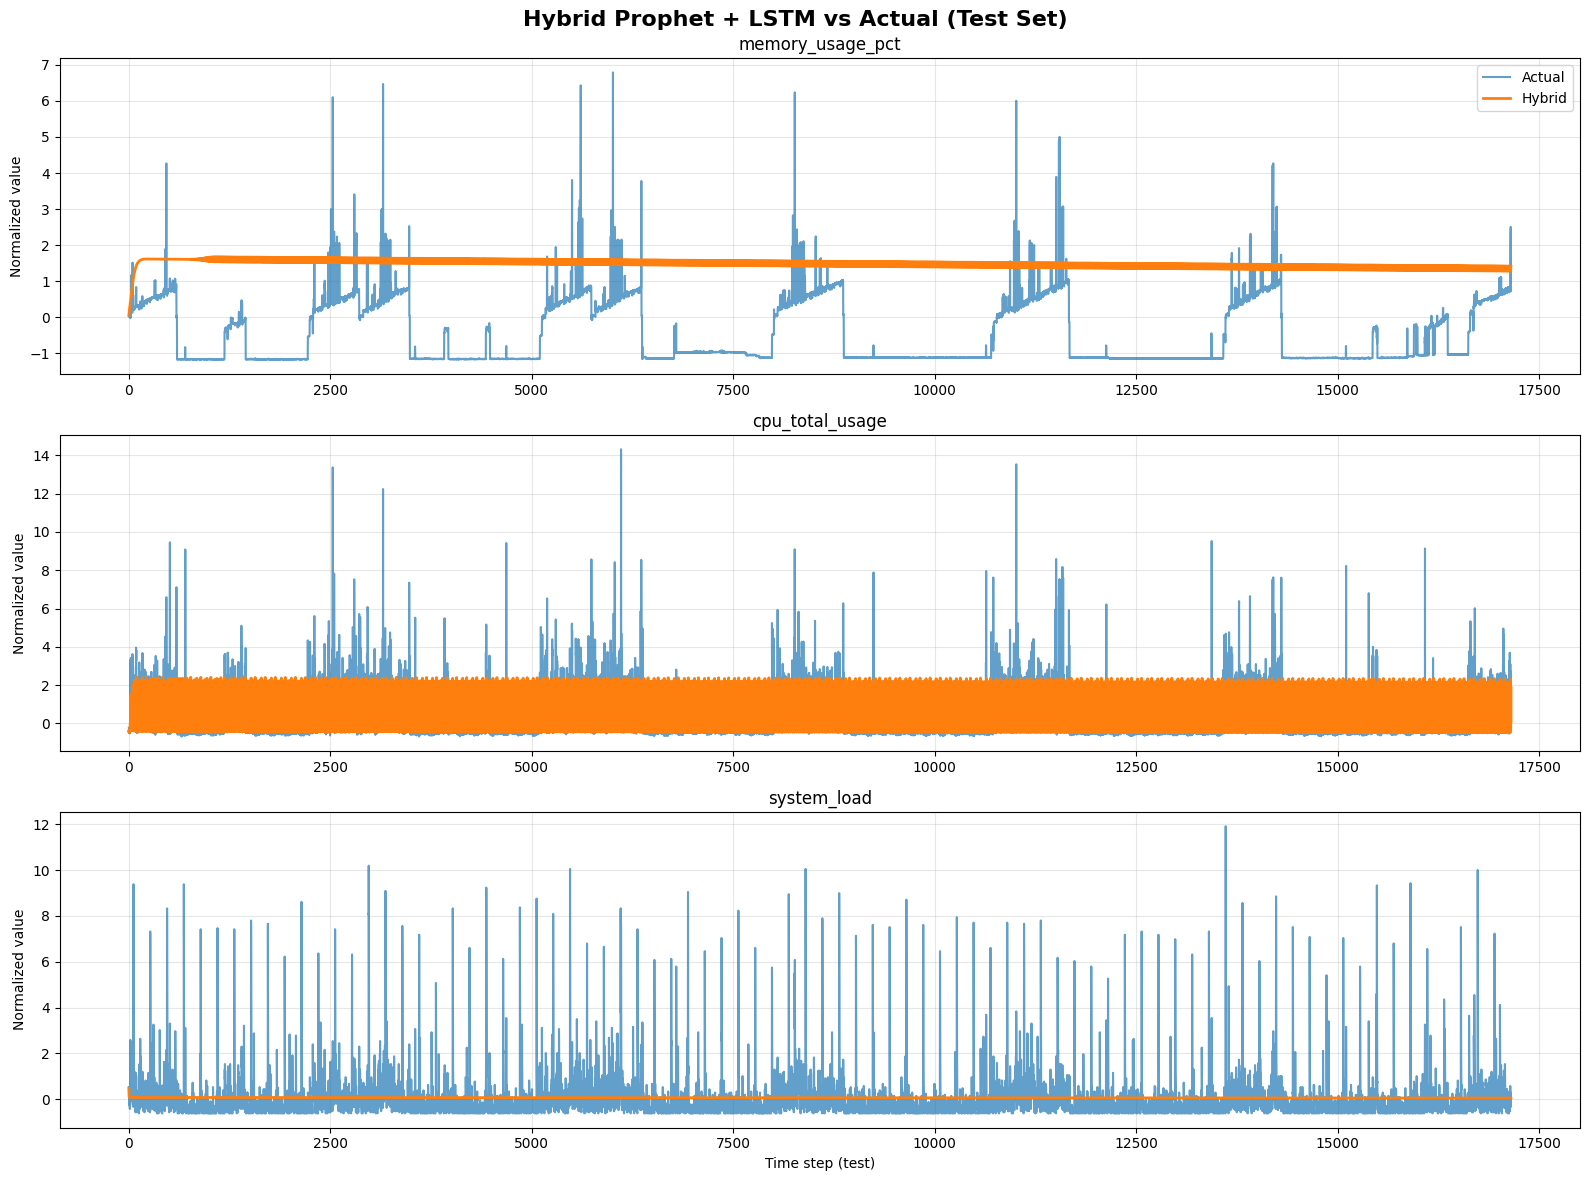

In [17]:
fig, axes = plt.subplots(len(TARGETS), 1, figsize=(16, 12), sharex=False)
fig.suptitle('Hybrid Prophet + LSTM vs Actual (Test Set)', fontsize=16, fontweight='bold')

for idx, target in enumerate(TARGETS):
    ax = axes[idx]
    data = prediction_store[target]
    ax.plot(data['y_test'], label='Actual', alpha=0.7)
    ax.plot(data['hybrid_test'], label='Hybrid', linewidth=2)
    ax.set_title(target)
    ax.set_ylabel('Normalized value')
    ax.grid(True, alpha=0.3)
    if idx == len(TARGETS) - 1:
        ax.set_xlabel('Time step (test)')
    if idx == 0:
        ax.legend()

plt.tight_layout()
plt.show()


In [18]:
results_payload = {
    'model': 'hybrid_prophet_lstm',
    'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'targets': detailed_results,
    'training': training_metadata,
    'config': {
        'prophet': PROPHET_CONFIG,
        'lstm': {
            'hidden_size': HIDDEN_SIZE,
            'num_layers': NUM_LAYERS,
            'dropout': DROPOUT,
            'epochs': EPOCHS,
            'batch_size': BATCH_SIZE,
            'learning_rate': LEARNING_RATE,
            'window_size': WINDOW_SIZE,
            'use_huber_loss': USE_HUBER_LOSS,
            'use_lr_scheduler': USE_LR_SCHEDULER,
            'use_early_stopping': USE_EARLY_STOPPING,
            'early_stop_patience': EARLY_STOP_PATIENCE,
            'lr_patience': LR_PATIENCE,
            'lr_factor': LR_FACTOR,
            'min_lr': MIN_LR,
            'grad_clip_max_norm': GRAD_CLIP_MAX_NORM,
        },
        'series_freq': SERIES_FREQ,
        'start_timestamp': START_TIMESTAMP.isoformat(),
    }
}

save_results(results_payload, str(RESULTS_FILE))


✓ Results saved: results_hybrid_prophet_lstm.json


'results_hybrid_prophet_lstm.json'